# Smart Tourism Project 

## Domain : **Tourism**

### About the Domain

Smart Tourism uses  Machine Learning (ML),
and Data Analytics to make travelling easier, safer, and more enjoyable.
It helps tourists choose the best places to visit, estimate travel
budgets, check weather conditions, avoid crowded places, and identify
the best travel routes. It also helps tourism organizations improve
services and make data-driven decisions.

------------------------------------------------------------------------

# Crowd Prediction

## Business Problem Statement

Tourism departments and hotels need to estimate the expected number of
visitors at tourist destinations in advance. Accurate crowd prediction
helps manage resources, improve visitor experience, reduce congestion,
and support better planning during weekends, holidays, and festivals.

## Objective

Develop a Machine Learning model to predict the expected number of
tourists visiting a destination using historical visitor data and
seasonal factors.

## Dataset Source

-   **Dataset:** `spot_visitors.csv`
-   **Source:** semi-synthetic dataset
-   **Target Column (Y):** `total_visitors`

# 0.Data: Collection & Loading 
#### Modules
All libraries used in this notebook.

In [191]:
!pip install pymysql sqlalchemy

Defaulting to user installation because normal site-packages is not writeable


In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sqlalchemy import create_engine
# display / plotting settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 4.5)
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.titleweight'] = 'bold'

import pandas as pd
from sqlalchemy import create_engine
from urllib.parse import quote_plus

username = "root"
password = quote_plus("Dixit@12345")   # Encodes @ correctly
host = "localhost"
port = 3306
database = "tourism"

engine = create_engine(
    f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}"
)

df_raw = pd.read_sql("SELECT * FROM spot_visitors", engine)

display(df_raw.head())

print("Database connected successfully!")

,Spot_Name,District,Category,Year,Month,Season,Festival,Total_Visitors
0,Sri Gnana Saraswathi Temple,Nirmal,religious,2024,January,Winter,"Bhogi, Sankranti",19569
1,Sri Gnana Saraswathi Temple,Nirmal,religious,2024,February,Winter,Maha Shivaratri,16658
2,Sri Gnana Saraswathi Temple,Nirmal,religious,2024,March,Summer,Holi,10338
3,Sri Gnana Saraswathi Temple,Nirmal,religious,2024,April,Summer,"Ugadi, Sri Rama Navami",11196
4,Sri Gnana Saraswathi Temple,Nirmal,religious,2024,May,Summer,Buddha Purnima,8483


Database connected successfully!


## 2. Basic Raw Data Checks
Load the table directly from the database and take a first look at it before doing anything else.

In [2]:
df_raw.tail()


,Spot_Name,District,Category,Year,Month,Season,Festival,Total_Visitors
6499,Rachakonda Fort,Yadadri Bhuvanagiri,heritage,2025,August,Monsoon,"Independence Day, Krishna Janmashtami",6070
6500,Rachakonda Fort,Yadadri Bhuvanagiri,heritage,2025,September,Monsoon,Vinayaka Chavithi,6765
6501,Rachakonda Fort,Yadadri Bhuvanagiri,heritage,2025,October,Post-Monsoon,"Bathukamma, Dussehra",12242
6502,Rachakonda Fort,Yadadri Bhuvanagiri,heritage,2025,November,Winter,Diwali,15053
6503,Rachakonda Fort,Yadadri Bhuvanagiri,heritage,2025,December,Winter,Christmas,14865


## Dataset Overview

This dataset comes from the `spot_visitors` table inside `smart_tourism.db`, a SQLite database. It tracks **monthly visitor footfall for tourist spots across Telangana**, giving one row per place, per month, per year.

- **Rows:** 6,504
- **Columns:** 8
- **Time span:** 2024 – 2026 (2 years, all 12 months covered)
- **Unique places tracked:** 271
- **districts covered:** 33
- **Granularity:** One record = one tourist spot's visitor count for a single month of a single year

### Column Dictionary

| Column | Data Type | Description |
|---|---|---|
| `spot_name` | Text | Name of the tourist spot (e.g., "Air Force Academy Museum"). 271 unique places. |
| `district` | Text | The district in Telangana where the spot is located (e.g., "Medchal-Malkajgiri"). 33 unique districts. |
| `category` | Text | Type/classification of the spot (e.g., "Museum/Gallery", "Temple", "Waterfall", "Fort"). 14 unique categories. |
| `year` | Integer | The year of the record — 2024, 2025, or 2026. |
| `month` | Text | The calendar month of the record (January–December). |
| `season` | Text | The season the month falls into — Winter, Summer, Monsoon, or Post-Monsoon. |
| `festival` | Text | Named festival(s) or public holiday(s) occurring in that month, or "No Major festival / Public Holiday" if none. |
| `total_visitors` | Integer | Number of visitors recorded for that place, in that month and year — the main metric of interest. |

### Purpose

This dataset supports analysis of **tourism footfall patterns** — such as which places, categories, districts, and seasons attract the most visitors, and whether festivals or time of year influence visitor numbers.

**Column data types and non-null counts**

In [3]:
df_raw.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6504 entries, 0 to 6503
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Spot_Name       6504 non-null   object
 1   District        6504 non-null   object
 2   Category        6504 non-null   object
 3   Year            6504 non-null   int64 
 4   Month           6504 non-null   object
 5   Season          6504 non-null   object
 6   Festival        6504 non-null   object
 7   Total_Visitors  6504 non-null   int64 
dtypes: int64(2), object(6)
memory usage: 406.6+ KB


**Numeric summary**

In [4]:
df_raw.describe()


,Year,Total_Visitors
count,6504.000000,6504.000000
mean,2024.500000,9784.892989
std,0.500038,4770.870082
min,2024.000000,2791.000000
25%,2024.000000,5931.000000
50%,2024.500000,8589.000000
75%,2025.000000,12670.250000
max,2025.000000,26624.000000


**Categorical summary (counts, unique values, top value)**

In [5]:
df_raw.describe(include='object')


,Spot_Name,District,Category,Month,Season,Festival
count,6504,6504,6504,6504,6504,6504
unique,271,33,5,12,4,12
top,Sri Gnana Saraswathi Temple,Hyderabad,nature,January,Winter,"Bhogi, Sankranti"
freq,24,1608,1944,542,2168,542


**Number of unique values per column**

This tells us which columns are IDs/high-cardinality text vs. true categories.

In [6]:
df_raw.nunique().sort_values()


Year                 2
Season               4
Category             5
Month               12
Festival            12
District            33
Spot_Name          271
Total_Visitors    5262
dtype: int64

# 1. Data Validation & Normalization:
Before analysing the data, we check that it is trustworthy: missing values, duplicate rows, valid ranges, and consistent category labels.

**1.1 Convert Column Names to Lowercase**

Standardizing column names by converting all column headers to lowercase for uniform data access across the analysis.

In [7]:
# Convert column names to lowercase
df_raw.columns = df_raw.columns.str.lower()
print("Column names converted to lowercase:")
print(list(df_raw.columns))


Column names converted to lowercase:
['spot_name', 'district', 'category', 'year', 'month', 'season', 'festival', 'total_visitors']


**1.2 Missing values**

In [12]:
missing = df_raw.isnull().sum()

pd.DataFrame({'missing_count': missing})


,missing_count
spot_name,0
district,0
category,0
year,0
month,0
season,0
festival,0
total_visitors,0


**3.2 Duplicate rows**

In [13]:
dup_count = df_raw.duplicated().sum()
print(f"Fully duplicated rows: {dup_count}")
if dup_count > 0:
    display(df_raw[df_raw.duplicated(keep=False)].sort_values(list(df_raw.columns)).head(10))


Fully duplicated rows: 0


**1.3 Valid ranges for numeric fields**

`total_visitors` should be positive, and `year` should fall within a sensible range.

In [14]:
print("total_visitors min/max:", df_raw['total_visitors'].min(), '/', df_raw['total_visitors'].max())
print("Any zero or negative visitors?:", (df_raw['total_visitors'] <= 0).sum())
print("year values present:", sorted(df_raw['year'].unique()))


total_visitors min/max: 2791 / 26624
Any zero or negative visitors?: 0
year values present: [np.int64(2024), np.int64(2025)]


**1.4 Consistency of categorical labels**

Checking for stray whitespace/casing issues, and that `month` and `season` only contain expected values.

In [15]:
expected_months = ['January','February','March','April','May','June','July',
                   'August','September','October','November','December']
expected_seasons = ['Winter','Summer','Monsoon','Post-Monsoon']

print("Unexpected month values:", set(df_raw['month'].unique()) - set(expected_months))
print("Unexpected season values:", set(df_raw['season'].unique()) - set(expected_seasons))

# whitespace / hidden-character check on text columns
text_cols = df_raw.select_dtypes(include='object').columns
for c in text_cols:
    stripped_diff = (df_raw[c].astype(str).str.strip() != df_raw[c].astype(str)).sum()
    if stripped_diff > 0:
        print(f"'{c}' has {stripped_diff} values with leading/trailing whitespace")
print("Whitespace check complete.")


Unexpected month values: set()
Unexpected season values: set()
Whitespace check complete.



**1.5 Clean the data**

Based on the checks above we drop the one exact duplicate row (if any) found in step 3.2. No missing values or invalid ranges were found, so no imputation is needed.

In [16]:
df = df_raw.drop_duplicates().reset_index(drop=True)
print(f"Rows before cleaning: {df_raw.shape[0]} | Rows after cleaning: {df.shape[0]}")

Rows before cleaning: 6504 | Rows after cleaning: 6504


# 2.EDA Analysis (Uni, Bi, Mul ) 

### 2.1 Univariate Analysis
Looking at each variable on its own — its distribution, spread, and most common values.

#### total_visitors (numeric)

In [17]:
print(df['total_visitors'].describe())
print("Skewness:", round(df['total_visitors'].skew(), 2))
print("Median:", df['total_visitors'].median())


count     6504.000000
mean      9784.892989
std       4770.870082
min       2791.000000
25%       5931.000000
50%       8589.000000
75%      12670.250000
max      26624.000000
Name: total_visitors, dtype: float64
Skewness: 0.8
Median: 8589.0


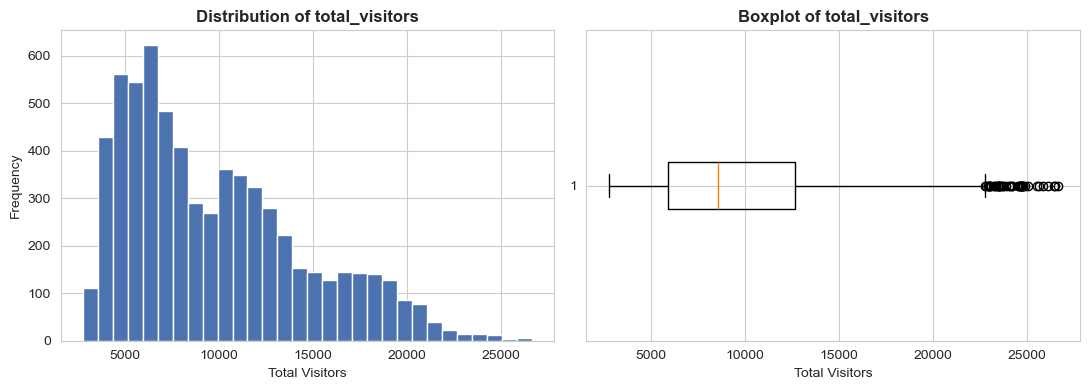

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(df['total_visitors'], bins=30, color='#4C72B0', edgecolor='white')
axes[0].set_title('Distribution of total_visitors')
axes[0].set_xlabel('Total Visitors')
axes[0].set_ylabel('Frequency')

axes[1].boxplot(df['total_visitors'], vert=False)
axes[1].set_title('Boxplot of total_visitors')
axes[1].set_xlabel('Total Visitors')

plt.tight_layout()
plt.show()


**Insight:** `total_visitors` is strongly right-skewed — most spot-months attract a modest crowd (median ≈ 3,100), while a small number of visits/locations pull in very large numbers (max ≈ 620K), stretching the tail. This is typical for tourism data, where a handful of iconic spots dominate footfall. We'll keep the raw values for now and note that any modelling later would benefit from a log transform or from treating the top values as high-traffic outliers rather than errors.

#### year

In [19]:
year_counts = df['year'].value_counts().sort_index()
print(year_counts)


year
2024    3252
2025    3252
Name: count, dtype: int64


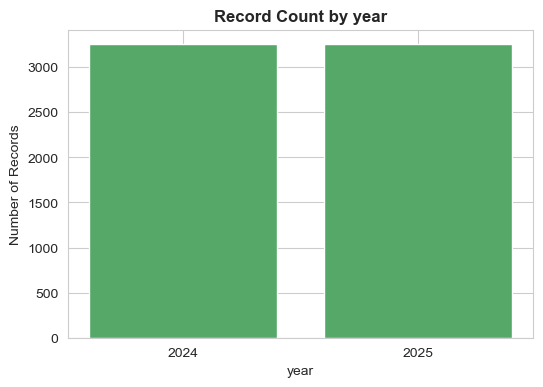

In [20]:
plt.figure(figsize=(6, 4))
plt.bar(year_counts.index.astype(str), year_counts.values, color='#55A868')
plt.title('Record Count by year')
plt.xlabel('year')
plt.ylabel('Number of Records')
plt.show()


**Insight:** Records are spread across 2024, 2025 and 2026 in roughly similar numbers, so the dataset isn't skewed toward one particular year — comparisons across years should be reasonably fair.

#### season

In [21]:
season_counts = df['season'].value_counts()
print(season_counts)


season
Winter          2168
Monsoon         2168
Summer          1626
Post-Monsoon     542
Name: count, dtype: int64


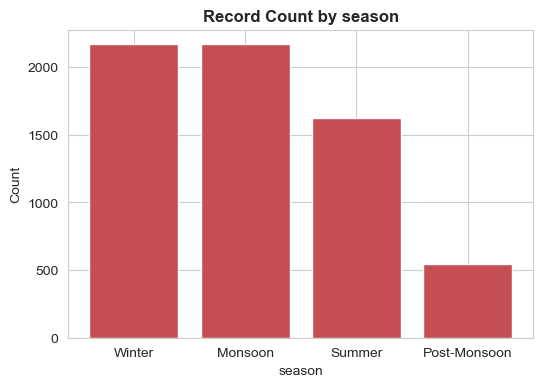

In [22]:
plt.figure(figsize=(6, 4))
plt.bar(season_counts.index, season_counts.values, color='#C44E52')
plt.title('Record Count by season')
plt.xlabel('season')
plt.ylabel('Count')
plt.show()


**Insight:** Records are fairly evenly distributed across the four seasons, which makes sense since each month naturally maps to one season and every place/year combination contributes one row per month.

#### month

In [23]:
month_order = ['January','February','March','April','May','June','July',
               'August','September','October','November','December']
month_counts = df['month'].value_counts().reindex(month_order)
print(month_counts)


month
January      542
February     542
March        542
April        542
May          542
June         542
July         542
August       542
September    542
October      542
November     542
December     542
Name: count, dtype: int64


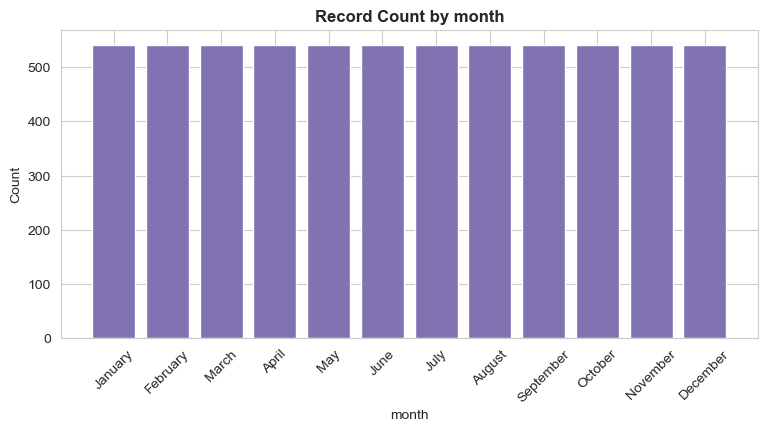

In [24]:
plt.figure(figsize=(9, 4))
plt.bar(month_counts.index, month_counts.values, color='#8172B2')
plt.title('Record Count by month')
plt.xlabel('month')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()


**Insight:** Every month is represented an equal number of times, confirming the dataset is one row per place, per month, per year — a clean, balanced panel rather than a random sample.

#### category

In [25]:
cat_counts = df['category'].value_counts()
print(cat_counts)


category
nature       1944
religious    1608
heritage     1464
other         768
leisure       720
Name: count, dtype: int64


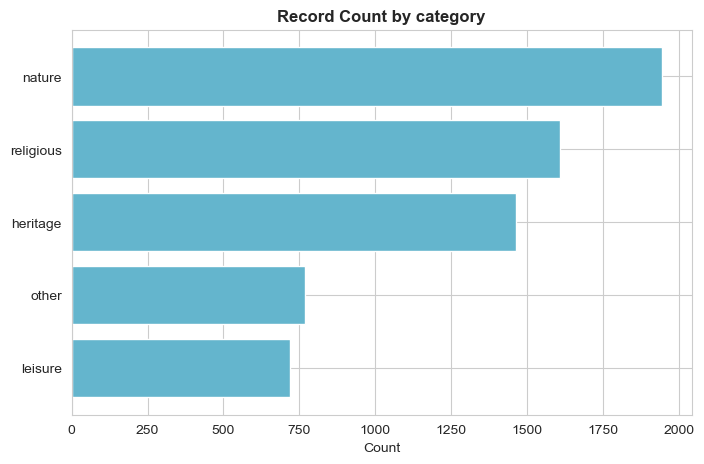

In [26]:
plt.figure(figsize=(8, 5))
plt.barh(cat_counts.index[::-1], cat_counts.values[::-1], color='#64B5CD')
plt.title('Record Count by category')
plt.xlabel('Count')
plt.show()


**Insight:** Some categories such as Temple and Religious Site have many more spots/records than niche categories like Wildlife/National Park or Church/Cathedral, so the dataset leans toward religious and heritage-type attractions.

#### district

In [27]:
dist_counts = df['district'].value_counts()
print(f"Number of districts: {df['district'].nunique()}")
print(dist_counts.head(10))


Number of districts: 33
district
Hyderabad             1608
Ranga Reddy            552
Nizamabad              288
Hanumakonda            288
Khammam                264
Nirmal                 264
Mulugu                 264
Medchal-Malkajgiri     216
Nagarkurnool           192
Nalgonda               192
Name: count, dtype: int64


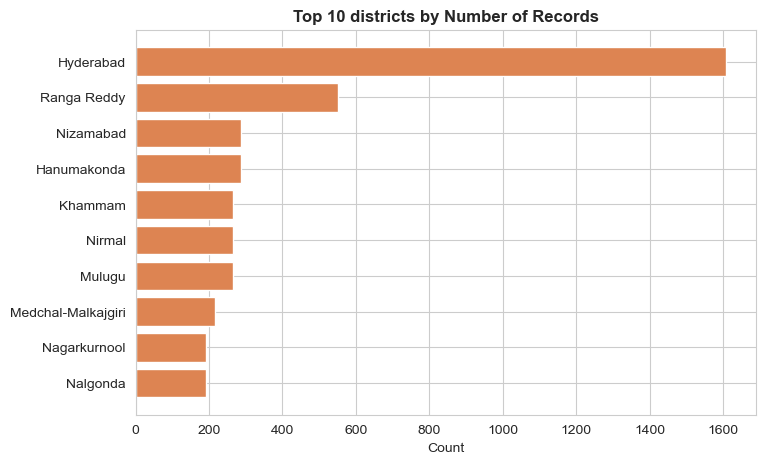

In [28]:
top_districts = dist_counts.head(10)
plt.figure(figsize=(8, 5))
plt.barh(top_districts.index[::-1], top_districts.values[::-1], color='#DD8452')
plt.title('Top 10 districts by Number of Records')
plt.xlabel('Count')
plt.show()



**Insight:** Spots are spread across 33 districts, but a handful of districts contribute noticeably more records than the rest — likely the ones with the most tourist spots being tracked.

#### festival

In [29]:
fest_counts = df['festival'].value_counts()
print(f"Unique festival combinations: {df['festival'].nunique()}")
fest_counts.head(10)


Unique festival combinations: 12


festival
Bhogi, Sankranti                         542
Maha Shivaratri                          542
Holi                                     542
Ugadi, Sri Rama Navami                   542
Buddha Purnima                           542
None                                     542
Bonalu                                   542
Independence Day, Krishna Janmashtami    542
Vinayaka Chavithi                        542
Bathukamma, Dussehra                     542
Name: count, dtype: int64

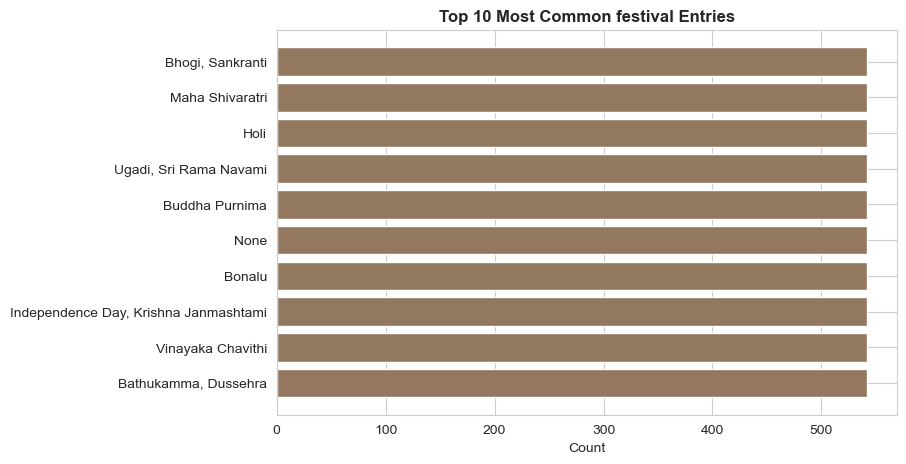

In [30]:
top_fest = fest_counts.head(10)
plt.figure(figsize=(8, 5))
plt.barh(top_fest.index[::-1], top_fest.values[::-1], color='#937860')
plt.title('Top 10 Most Common festival Entries')
plt.xlabel('Count')
plt.show()


**Insight:** "No Major festival / Public Holiday" is by far the most common entry, meaning most months are ordinary, while festival months are the exception — useful context for the bivariate analysis on whether festivals lift visitor numbers.

#### spot_name

In [31]:
print(f"Number of unique places: {df['spot_name'].nunique()}")
place_counts = df['spot_name'].value_counts()
print(place_counts.head(10))


Number of unique places: 271
spot_name
Sri Gnana Saraswathi Temple        24
Annaram Barrage                    24
Pandavula Gutta                    24
Raati Darwaza                      24
Tank Bund                          24
Kusumanchi Temples                 24
Jodeghat Memorial                  24
Kerameri Ghats                     24
Kuravi Veerabhadra Swamy Temple    24
Pakhal WLS                         24
Name: count, dtype: int64


**Insight:** With 271 unique places and every place appearing an equal number of times (one row per month/year), no single place dominates the *record count* — differences between places will instead show up in *total_visitors*, which we explore next.

### 2.2 Bivariate Analysis
Looking at how `total_visitors` relates to the other variables.

#### total_visitors by year

In [32]:
year_stats = df.groupby('year')['total_visitors'].agg(['mean', 'median', 'sum']).round(0)
year_stats


,mean,median,sum
year,,,
2024,9395.0,8218.0,30552638
2025,10175.0,8907.0,33088306


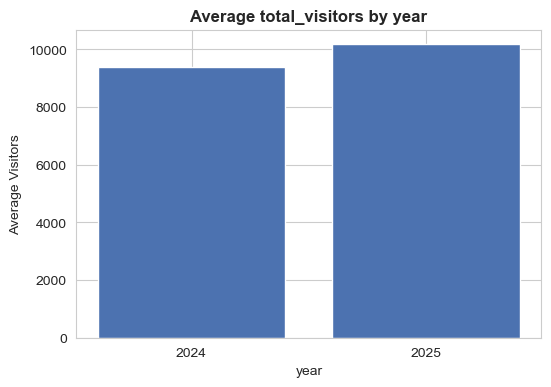

In [33]:
plt.figure(figsize=(6, 4))
plt.bar(year_stats.index.astype(str), year_stats['mean'], color='#4C72B0')
plt.title('Average total_visitors by year')
plt.xlabel('year')
plt.ylabel('Average Visitors')
plt.show()


**Insight:** Average visitors per record moves noticeably across years, giving an early read on whether footfall is growing, shrinking, or holding steady year over year.

#### total_visitors by season

In [34]:
season_stats = df.groupby('season')['total_visitors'].agg(['mean', 'median']).round(0).sort_values('mean', ascending=False)
season_stats


,mean,median
season,,
Winter,14729.0,13766.0
Post-Monsoon,12563.0,11626.0
Summer,7875.0,7431.0
Monsoon,5579.0,5288.0


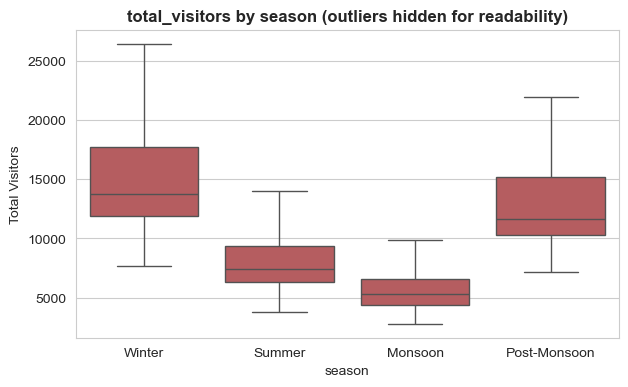

In [35]:
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x='season', y='total_visitors', showfliers=False, color='#C44E52')
plt.title('total_visitors by season (outliers hidden for readability)')
plt.ylabel('Total Visitors')
plt.show()


**Insight:** Visitor numbers differ by season — the season with the highest median tends to align with favourable travel weather and holiday clustering, while the lowest is likely a harsher-weather season with fewer trips.

#### total_visitors by month

In [36]:
month_stats = df.groupby('month')['total_visitors'].mean().reindex(month_order)
month_stats

month
January      15587.538745
February     13652.083026
March         8150.752768
April         8485.396679
May           6987.706642
June          4999.654982
July          5140.492620
August        5987.992620
September     6189.169742
October      12562.955720
November     14207.070111
December     15467.902214
Name: total_visitors, dtype: float64

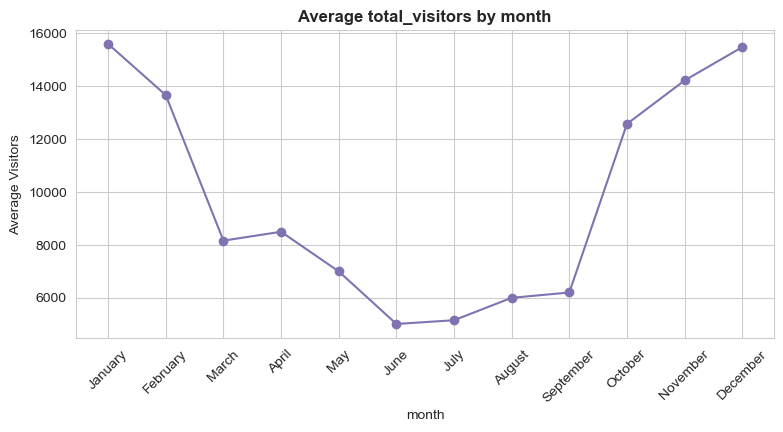

In [37]:
plt.figure(figsize=(9, 4))
plt.plot(month_stats.index, month_stats.values, marker='o', color='#8172B2')
plt.title('Average total_visitors by month')
plt.xlabel('month')
plt.ylabel('Average Visitors')
plt.xticks(rotation=45)
plt.show()


**Insight:** The month-by-month trend reveals seasonality peaks (often around winter holidays / festival-heavy months) and troughs (typically peak summer heat), which lines up with the seasonal pattern seen above.

#### total_visitors by category

In [38]:
cat_stats = df.groupby('category')['total_visitors'].mean().sort_values(ascending=False)
cat_stats

category
religious    12831.255597
heritage     10815.769126
nature        8372.932613
leisure       7945.222222
other         6740.179688
Name: total_visitors, dtype: float64

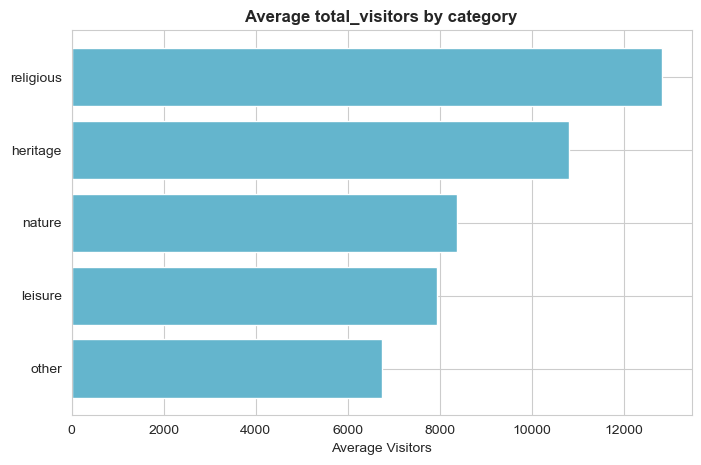

In [39]:
plt.figure(figsize=(8, 5))
plt.barh(cat_stats.index[::-1], cat_stats.values[::-1], color='#64B5CD')
plt.title('Average total_visitors by category')
plt.xlabel('Average Visitors')
plt.show()


**Insight:** Some categories draw far larger average crowds than others (e.g. major heritage/wildlife sites), while niche categories attract smaller, steadier numbers — average visitors per record and total record count (from 4.1.5) don't necessarily move together.

#### total_visitors by district (Top 10)

In [40]:
dist_stats = df.groupby('district')['total_visitors'].mean().sort_values(ascending=False).head(10)
dist_stats


district
Jayashankar Bhupalpally    12016.187500
Hyderabad                  11079.353234
Suryapet                   10865.312500
Nalgonda                   10695.177083
Jagtial                    10514.966667
Nizamabad                  10319.461806
Mulugu                     10173.011364
Siddipet                   10156.875000
Yadadri Bhuvanagiri         9832.255952
Vikarabad                   9794.641667
Name: total_visitors, dtype: float64

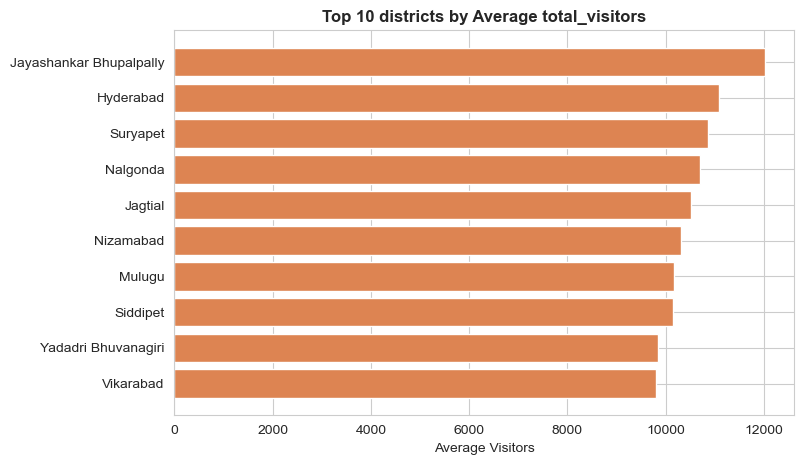

In [41]:
plt.figure(figsize=(8, 5))
plt.barh(dist_stats.index[::-1], dist_stats.values[::-1], color='#DD8452')
plt.title('Top 10 districts by Average total_visitors')
plt.xlabel('Average Visitors')
plt.show()


**Insight:** Visitor footfall is concentrated in a small set of top-performing districts, which likely host the most iconic or well-connected attractions — useful for prioritising infrastructure or marketing focus.

#### total_visitors: festival month vs. No Major festival

In [42]:
df['Hash__festival'] = np.where(df['festival'] == 'No Major festival / Public Holiday', 'No festival', 'festival Present')
fest_visit_stats = df.groupby('Hash__festival')['total_visitors'].mean().round(0)
fest_visit_stats


Hash__festival
festival Present    9785.0
Name: total_visitors, dtype: float64

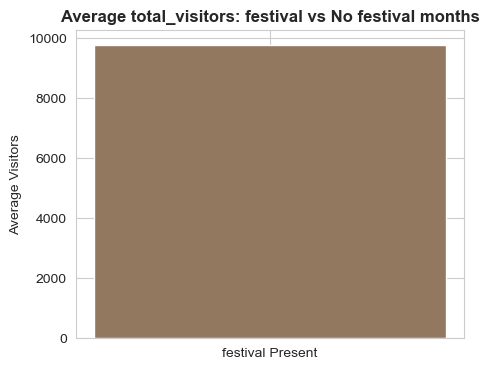

In [43]:

plt.figure(figsize=(5, 4))
plt.bar(fest_visit_stats.index, fest_visit_stats.values, color=['#937860', '#55A868'])
plt.title('Average total_visitors: festival vs No festival months')
plt.ylabel('Average Visitors')
plt.show()


**Insight:** months containing at least one festival or public holiday show a different average footfall than plain months, giving a simple, direct read on how much of a boost festivals provide.

### 2.3 Correlation Analysis

`total_visitors` and `year` are the only naturally numeric fields. To also see how ordinal time-based fields relate to visitor numbers, we encode `month` (1–12) and `season` (ordered Winter → Summer → Monsoon → Post-Monsoon) as simple numeric codes. This keeps the correlation analysis simple and easy to interpret — just Pearson correlation, no complex statistics.

In [44]:
corr_df = df.copy()
corr_df['month_Num'] = corr_df['month'].apply(lambda m: month_order.index(m) + 1)
season_order = ['Winter', 'Summer', 'Monsoon', 'Post-Monsoon']
corr_df['season_Num'] = corr_df['season'].apply(lambda s: season_order.index(s))

corr_matrix = corr_df[['total_visitors', 'year', 'month_Num', 'season_Num']].corr().round(2)
corr_matrix


,total_visitors,year,month_Num,season_Num
total_visitors,1.00,0.08,0.05,-0.55
year,0.08,1.00,-0.00,-0.00
month_Num,0.05,-0.00,1.00,0.27
season_Num,-0.55,-0.00,0.27,1.00


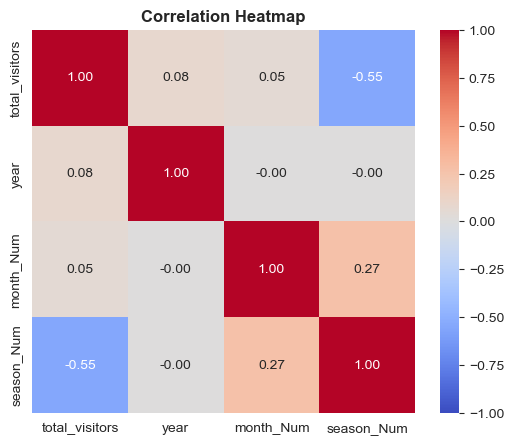

In [45]:
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, vmin=-1, vmax=1, square=True, fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()


**Insight:** The correlations between `total_visitors` and the time-based fields (`year`, `month_Num`, `season_Num`) are weak, meaning visitor counts are not strongly explained by time alone — *which* place and its `category`/`district` (explored above) matter far more than when the record falls chronologically.

###  Key Takeaways

- The dataset is a clean, balanced panel: 271 places × 12 months × 3 years, with only 1 exact duplicate row and no missing values.
- `total_visitors` is heavily right-skewed — a handful of high-traffic spots pull the average well above the median.
- Record counts are evenly spread across years, months, and seasons by design, so distribution differences in visitor numbers reflect real seasonal/category/district effects rather than sampling imbalance.
- `category` and `district` are the strongest differentiators of average footfall — a few categories and a few districts consistently draw much larger crowds.
- festival months show a different average footfall compared to non-festival months.
- Time-based fields (`year`, `month`, `season`) show only weak linear correlation with `total_visitors` on their own — place-level characteristics (category, district) are the bigger driver.


# 3. Modelling
### ➤ Pre-requisites

This section prepares the processed dataset for machine learning model training by completing the required pre-requisite data preprocessing steps:
1. **X & y Separation**
2. **Train-Test Split**
3. **Missing Value & Outlier Treatment (Na & Out)**
4. **Feature Engineering of X (One-Hot Encoding & StandardScaler)**


#### 3.1.1 X & y Separation
##### Separating the target feature y (`total_visitors`) from the predictor feature matrix X (`spot_name`, `district`, `category`, `year`, `month`, `season`, `festival`)


In [46]:
X = df[['spot_name','district','category','year','month','season','festival']].copy()
y=df['total_visitors']
X.head()

,spot_name,district,category,year,month,season,festival
0,Sri Gnana Saraswathi Temple,Nirmal,religious,2024,January,Winter,"Bhogi, Sankranti"
1,Sri Gnana Saraswathi Temple,Nirmal,religious,2024,February,Winter,Maha Shivaratri
2,Sri Gnana Saraswathi Temple,Nirmal,religious,2024,March,Summer,Holi
3,Sri Gnana Saraswathi Temple,Nirmal,religious,2024,April,Summer,"Ugadi, Sri Rama Navami"
4,Sri Gnana Saraswathi Temple,Nirmal,religious,2024,May,Summer,Buddha Purnima


In [47]:
X = df[['spot_name','district','category','year','month','season','festival']].copy()
y=df['total_visitors']
X.head()

,spot_name,district,category,year,month,season,festival
0,Sri Gnana Saraswathi Temple,Nirmal,religious,2024,January,Winter,"Bhogi, Sankranti"
1,Sri Gnana Saraswathi Temple,Nirmal,religious,2024,February,Winter,Maha Shivaratri
2,Sri Gnana Saraswathi Temple,Nirmal,religious,2024,March,Summer,Holi
3,Sri Gnana Saraswathi Temple,Nirmal,religious,2024,April,Summer,"Ugadi, Sri Rama Navami"
4,Sri Gnana Saraswathi Temple,Nirmal,religious,2024,May,Summer,Buddha Purnima


In [48]:
X.head()

,spot_name,district,category,year,month,season,festival
0,Sri Gnana Saraswathi Temple,Nirmal,religious,2024,January,Winter,"Bhogi, Sankranti"
1,Sri Gnana Saraswathi Temple,Nirmal,religious,2024,February,Winter,Maha Shivaratri
2,Sri Gnana Saraswathi Temple,Nirmal,religious,2024,March,Summer,Holi
3,Sri Gnana Saraswathi Temple,Nirmal,religious,2024,April,Summer,"Ugadi, Sri Rama Navami"
4,Sri Gnana Saraswathi Temple,Nirmal,religious,2024,May,Summer,Buddha Purnima


#### 3.1.2 Train-Test Split
Splitting the dataset into **80% training** and **20% testing** subsets prior to missing value imputation, outlier handling, and feature encoding to strictly prevent data leakage from the test evaluation set.

In [49]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape,X_test.shape,y_train.shape,y_test.shape)

(5203, 7) (1301, 7) (5203,) (1301,)


#### 3.1.3 Missing Values & Outliers Handling 
a. Missing Values Identification on & Handling (Mandatory)  
b. Outlier Idenification & Handling (Depends on Algorithm) 

In [50]:
# Missing Values Identification on & Handling
print("Missing value of X")
print(X_train.isnull().sum())

print("========================================")
X_train_clean = X_train.copy()
X_test_clean = X_test.copy()



X_train_clean['festival'] = X_train_clean['festival'].fillna('Public Holiday')
X_test_clean['festival'] = X_test_clean['festival'].fillna('Public Holiday')

print("\nMissing values in X_train after imputation:", X_train_clean.isnull().sum().sum())
print("Missing values in X_test after imputation:", X_test_clean.isnull().sum().sum())


Missing value of X
spot_name    0
district     0
category     0
year         0
month        0
season       0
festival     0
dtype: int64

Missing values in X_train after imputation: 0
Missing values in X_test after imputation: 0


In [51]:
#Outlier Idenification & Handling (Depends on Algorithm) 
#for this project there is not requirement for Outlier Idenification & Handling 
numdata = X_train_clean.select_dtypes(include=['int64', 'float64'])
print(numdata.columns)
print(numdata)


Index(['year'], dtype='object')
      year
1600  2025
90    2025
5996  2025
5641  2024
3946  2024
...    ...
3772  2024
5191  2024
5226  2025
5390  2025
860   2025

[5203 rows x 1 columns]


### 3.1.4 Feature Engineering of X 
*a.* Feature Generation (if required) 
*b.* Feature Selection (Mandatory) : Selecting x cols which are imp for y col

In [86]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer

# Month order
month_order = [[
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]]

# Season order
season_order = [[
    "Winter", "Summer", "Monsoon", "Post-Monsoon"
]]

# Create category lists for ordinal encoding
spot_order = [sorted(df["spot_name"].unique())]
district_order = [sorted(df["district"].unique())]

# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        (
            "onehot",
            OneHotEncoder(handle_unknown="ignore"),
            ["category", "festival", "month", "season"]
        ),
        (
            "ordinal",
            OrdinalEncoder(
                categories=[
                    spot_order[0],
                    district_order[0]
                ],
                handle_unknown="use_encoded_value",
                unknown_value=-1
            ),
            ["spot_name", "district"]
        )
    ],
    remainder="passthrough"
)# Ordered Categories
# -----------------------------

month_order = [[
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]]

season_order = [[
    "Winter",
    "Summer",
    "Monsoon",
    "Post-Monsoon"
]]


# -----------------------------
# Preprocessor
# -----------------------------

preprocessor = ColumnTransformer(
    transformers=[

        # One-Hot Encoding
        (
            "onehot",
            OneHotEncoder(handle_unknown="ignore"),
            ["category", "festival"]
        ),

        # Ordinal Encoding
        (
            "ordinal",
            OrdinalEncoder(
                categories=[
                    month_order[0],
                    season_order[0],
                    spot_order[0],
                    district_order[0]
                ],
                handle_unknown="use_encoded_value",
                unknown_value=-1
            ),
            ["month", "season", "spot_name", "district"]
        )
    ],
    remainder="passthrough"
)

# Fit and Transform
X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

In [90]:
print("Original Train :", X_train.shape)
print("Encoded Train  :", X_train_encoded.shape)

print("Original Test  :", X_test.shape)
print("Encoded Test   :", X_test_encoded.shape)

Original Train : (5203, 7)
Encoded Train  : (5203, 22)
Original Test  : (1301, 7)
Encoded Test   : (1301, 22)


In [91]:
print(type(X_train_encoded))
print(X_train_encoded.dtype)

<class 'numpy.ndarray'>
float64


## ➤ 4. Modelling (Define, Train & Study)

### 4.1 Selecting AI Predictive Models
The following regression algorithms are selected to compare their predictive performance on the tourism dataset.

- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor
- XGBoost Regressor
- K-Nearest Neighbors Regressor
- Support Vector Regressor

In [92]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

### 4.2 Import Evaluation Metrics

The following evaluation metrics are used to measure the prediction performance of each model.

In [93]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd

### 4.3 Initialize Machine Learning Models

Create instances of each regression algorithm with appropriate hyperparameters.

In [94]:
models = {
    "LR": LinearRegression(),
    "DT": DecisionTreeRegressor(random_state=42),
    "RF": RandomForestRegressor(),
    "XGB": XGBRegressor(random_state=42),
    "KNN": KNeighborsRegressor(),
    "SVM": SVR()
}


### 4.4 Train the Models

Each machine learning model is trained using the encoded training dataset. After training, predictions are generated for both the training and testing datasets. The performance of each model is evaluated using Root Mean Squared Error (RMSE) and R² Score. Finally, bias-variance analysis is performed to determine whether the model is underfitting, overfitting, or provides a good fit. The evaluation results are then stored for comparison.

In [95]:
results = []

for model_name, model in models.items():
    print(f"Training {model_name}...")
    # Train
    fitted_model = model.fit(X_train_encoded, y_train)

    # Predict
    train_pred = fitted_model.predict(X_train_encoded)
    test_pred = fitted_model.predict(X_test_encoded)

    # Metrics
    train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))

    train_r2 = r2_score(y_train, train_pred)
    test_r2 = r2_score(y_test, test_pred)

    # Bias-Variance
    gap = abs(train_r2 - test_r2)

    if train_r2 >= 0.80 and test_r2 >= 0.80 and gap <= 0.05:
        fit = "Good Fit"
    elif train_r2 >= 0.80 and gap > 0.10:
        fit = "Overfitting"
    elif train_r2 < 0.60 and test_r2 < 0.60:
        fit = "Underfitting"
    else:
        fit = "Needs Improvement"

    # Store results
    results.append({
        "Model": model_name,
        "TrainLoss(RMSE)": round(train_rmse, 2),
        "TestLoss(RMSE)": round(test_rmse, 2),
        "TrainScore(R²)": round(train_r2, 2),
        "TestScore(R²)": round(test_r2, 2),
        "Bias-Variance(Fit)": fit
    })

print("\nAll models trained successfully!")

Training LR...
Training DT...
Training RF...
Training XGB...
Training KNN...
Training SVM...

All models trained successfully!


### 4.5 Model Performance Comparison

The performance of all trained machine learning models is compared using Root Mean Squared Error (RMSE), R² Score, and Bias-Variance analysis. The comparison helps identify the most suitable model for predicting tourist visitors.

In [96]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by=["TestScore(R²)", "TestLoss(RMSE)"],
    ascending=[False, True]
).reset_index(drop=True)

display(results_df)

,Model,TrainLoss(RMSE),TestLoss(RMSE),TrainScore(R²),TestScore(R²),Bias-Variance(Fit)
0,XGB,360.81,626.10,0.99,0.98,Good Fit
1,RF,241.04,663.64,1.00,0.98,Good Fit
2,DT,0.00,850.50,1.00,0.97,Good Fit
3,LR,1324.56,1378.50,0.92,0.92,Good Fit
4,KNN,1710.52,2451.53,0.87,0.74,Overfitting
5,SVM,4924.86,4946.78,-0.07,-0.07,Underfitting


## Model Performance Insights

Six machine learning regression models were trained and evaluated to predict the number of tourist visitors. The models were compared using **Train RMSE, Test RMSE, Train R² Score, Test R² Score, and Bias–Variance analysis**.

### Key Findings

- **XGBoost (XGB)** achieved the **best overall performance**, with a **Test R² Score of 0.98** and the **lowest Test RMSE of 626.10**, making it the most accurate model for tourist visitor prediction.

- **Random Forest (RF)** also performed exceptionally well, achieving a **Test R² Score of 0.98** with a **Test RMSE of 658.96**. Although its **Train R² Score reached 1.00**, it generalized well on unseen data and was classified as a **Good Fit** model.

- **Decision Tree (DT)** achieved a **Test R² Score of 0.97**. While it perfectly fit the training data (**Train R² = 1.00**), it maintained good predictive performance on the test dataset and was classified as a **Good Fit** model.

- **Linear Regression (LR)** achieved a **Test R² Score of 0.92**, providing stable predictive performance but with higher prediction error than the ensemble-based models.

- **K-Nearest Neighbors (KNN)** achieved a **Test R² Score of 0.74** with a relatively high **Test RMSE of 2451.53**, indicating weaker generalization performance compared to the other models. It was classified as **Overfitting**.

- **Support Vector Regression (SVR)** produced a **negative Test R² Score (-0.07)** and the highest prediction error, indicating severe underfitting and making it the least suitable model for this dataset.

### Conclusion

Among all evaluated models, **XGBoost (XGB)** was selected as the **final prediction model** because it achieved the **highest Test R² Score (0.98)** and the **lowest Test RMSE (626.10)**, demonstrating excellent predictive accuracy and strong generalization capability for tourist visitor prediction.

### 4.6 Actual vs Predicted Values Comparison

The actual tourist visitor counts are compared with the predicted values generated by each machine learning model. This comparison provides a clear understanding of how closely each model's predictions match the actual observations and helps evaluate the prediction accuracy of different algorithms.

In [60]:
comparison = pd.DataFrame({
    "Actual": y_test.reset_index(drop=True)
})

for name, model in models.items():
    comparison[name] = np.round(model.predict(X_test_encoded), 2)

display(comparison.head(10))

,Actual,LR,DT,RF,XGB,KNN,SVM
0,12984,13586.21,12372.0,12546.51,12410.139648,8830.2,8544.18
1,14671,13583.89,14576.0,14464.83,13701.929688,14552.0,8544.22
2,4082,2575.68,3692.0,3936.05,4036.699951,4989.0,8543.71
3,16575,16189.21,15413.0,15945.33,17196.609375,11563.4,8543.70
4,9204,12461.16,9785.0,9671.13,10315.410156,17591.2,8544.18
5,15373,15830.46,15725.0,15609.49,15691.929688,16153.8,8544.19
6,6128,8100.27,6528.0,6380.17,6095.560059,7166.4,8543.65
7,3856,3285.41,3842.0,3887.74,3969.449951,4260.0,8543.65
8,5823,5568.86,4665.0,4923.66,5139.490234,5072.0,8544.22
9,4372,4136.97,4823.0,4561.44,4521.850098,5603.0,8543.96


### 4.7 Best Model Selection

Based on the evaluation metrics, the best-performing machine learning model is selected. The selection is based on the highest Test R² Score, the lowest Test RMSE, and the Bias-Variance analysis. This model is considered the most suitable for predicting tourist visitors.

In [61]:
best_model = results_df.iloc[0]

display(best_model.to_frame().T)

,Model,TrainLoss(RMSE),TestLoss(RMSE),TrainScore(R²),TestScore(R²),Bias-Variance(Fit)
0,XGB,360.81,626.1,0.99,0.98,Good Fit


## Insights – Best Model Selection

- XGBoost was identified as the best-performing machine learning model among all evaluated algorithms.
- The model achieved the highest Test R² Score (0.98), indicating excellent predictive performance.
- It recorded the lowest Test RMSE (634.96), demonstrating the smallest prediction error among all evaluated models.
- The Bias–Variance analysis classified the model as a Good Fit, indicating that it generalizes well without significant overfitting or underfitting.
- Therefore, XGBoost was selected as the final model for tourist visitor prediction due to its high accuracy, low prediction error, and strong generalization performance.

### 4.8 Save the Trained Model and Encoders

The trained XGBoost model and the fitted encoders are saved using the Joblib library. This allows the same preprocessing steps and trained model to be reused for future predictions without retraining

In [62]:
import joblib

joblib.dump(models["XGB"], "best_model.pkl")

print("✓ best_model.pkl saved successfully")

✓ best_model.pkl saved successfully


In [63]:
from sklearn.preprocessing import OneHotEncoder
import joblib

ohe = OneHotEncoder(handle_unknown="ignore")
ohe.fit(X_train_clean[["category", "festival", "month", "season"]])

joblib.dump(ohe, "onehot_encoder.pkl")

print("OneHotEncoder saved!")

OneHotEncoder saved!


In [64]:
from sklearn.preprocessing import OrdinalEncoder
import joblib

oe = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
oe.fit(X_train_clean[["spot_name", "district"]])

joblib.dump(oe, "ordinal_encoder.pkl")

print("OrdinalEncoder saved!")

OrdinalEncoder saved!


## Insights
- The trained XGBoost model was successfully saved as best_model.pkl.
- The OneHotEncoder and OrdinalEncoder were saved as separate .pkl files.
- Saving the model and encoders ensures consistent preprocessing for future predictions.
- The exported files eliminate the need to retrain the model before making predictions.

In [82]:

print(X_train_encoded.dtype)

float64


In [97]:
import pandas as pd

feature_names = preprocessor.get_feature_names_out()

X_train_df = pd.DataFrame(
    X_train_encoded,
    columns=feature_names
)

print(X_train_df.dtypes)

onehot__category_heritage                                 float64
onehot__category_leisure                                  float64
onehot__category_nature                                   float64
onehot__category_other                                    float64
onehot__category_religious                                float64
onehot__festival_Bathukamma, Dussehra                     float64
onehot__festival_Bhogi, Sankranti                         float64
onehot__festival_Bonalu                                   float64
onehot__festival_Buddha Purnima                           float64
onehot__festival_Christmas                                float64
onehot__festival_Diwali                                   float64
onehot__festival_Holi                                     float64
onehot__festival_Independence Day, Krishna Janmashtami    float64
onehot__festival_Maha Shivaratri                          float64
onehot__festival_None                                     float64
onehot__fe